<a href="https://colab.research.google.com/github/Nikhil-Tanwar/PyTorch/blob/main/02_neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Classification

## Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch

In [2]:
from sklearn.datasets import make_circles
n_samples = 1000
X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(X[:5]), print(y[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
[1 1 1 1 0]


(None, None)

In [5]:
X.shape, y.shape

((1000, 2), (1000,))

In [6]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [7]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [8]:
# Making dataframe of cicle data
circles = pd.DataFrame({"X1" : X[:, 0], "X2" : X[:, 1], "label" : y})
circles.head()


,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


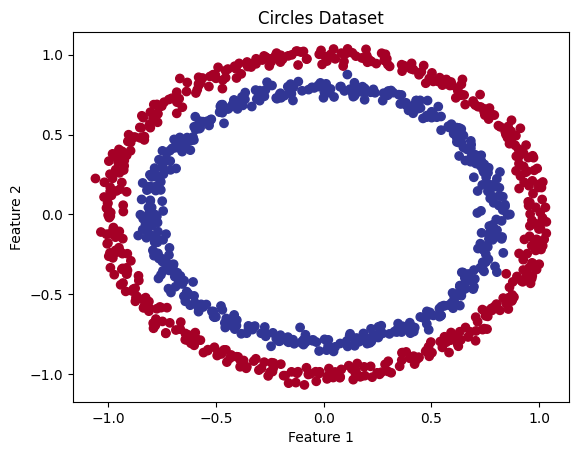

In [9]:
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c =y,
            cmap=plt.cm.RdYlBu)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Circles Dataset")
plt.show()

In [10]:
circles.label.value_counts()

,count
label,
1,500
0,500


In [11]:
type(X)

numpy.ndarray

NumPy default dtype is float64.

In [12]:
X.dtype

dtype('float64')

In [13]:
# Converting numpy array into tensors to pass into Pytorch
X = torch.from_numpy(np.array(X)).float()
y = torch.from_numpy(y).type(torch.float)

In [14]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

Tensor default dtype is float32


In [15]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [18]:
# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [19]:
from torch import nn

class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self,x: torch.Tensor) -> torch.Tensor:
    return self.layer_2(self.layer_1(x))

# return `self.layer_2(F.relu(self.layer_1(x)))` --> it implements reLU just before output, using inplace = False

# Instantiating an instance of model
model_0 = CircleModelV0().to(device)
model_0, model_0.state_dict()

# logits are from -inf to +inf - apply sigmoid bounds them from [0,1] --> threshold - 0's and 1's

(CircleModelV0(
   (layer_1): Linear(in_features=2, out_features=5, bias=True)
   (layer_2): Linear(in_features=5, out_features=1, bias=True)
 ),
 OrderedDict([('layer_1.weight',
               tensor([[ 0.6042, -0.6814],
                       [ 0.0926,  0.6557],
                       [ 0.3493,  0.5063],
                       [ 0.5937,  0.4102],
                       [-0.5091,  0.6005]], device='cuda:0')),
              ('layer_1.bias',
               tensor([-0.0290,  0.0125, -0.4543,  0.4344, -0.6717], device='cuda:0')),
              ('layer_2.weight',
               tensor([[-0.0244,  0.3552, -0.3657, -0.3442,  0.1510]], device='cuda:0')),
              ('layer_2.bias', tensor([0.3772], device='cuda:0'))]))

In [20]:
next(model_0.parameters()).device

device(type='cuda', index=0)

* Weight dim in layer - (out_features, in_features{prev layer}) --> to get X*W.T
* Could have linked layers via Sequential
* BCEWithLogitLoss - loss from z only

#### Sequential

In [21]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0, model_0.state_dict()

(Sequential(
   (0): Linear(in_features=2, out_features=5, bias=True)
   (1): Linear(in_features=5, out_features=1, bias=True)
 ),
 OrderedDict([('0.weight',
               tensor([[-0.0554, -0.6873],
                       [ 0.3380,  0.4704],
                       [ 0.5036, -0.0398],
                       [ 0.1828, -0.6845],
                       [ 0.4465, -0.0224]], device='cuda:0')),
              ('0.bias',
               tensor([-0.1287, -0.3397,  0.6505, -0.3564, -0.0934], device='cuda:0')),
              ('1.weight',
               tensor([[ 0.3465,  0.0885, -0.3429, -0.3919,  0.0256]], device='cuda:0')),
              ('1.bias', tensor([-0.0927], device='cuda:0'))]))

In [22]:
# Prediction or Inference
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
untrained_preds[:5], untrained_preds.shape, y_test[:5], y_test.shape
# As all logits are +ve --> pred = 1 --> model is not trained yet

(tensor([[-0.1119],
         [-0.1752],
         [-0.1237],
         [-0.1078],
         [-0.4057]], device='cuda:0'),
 torch.Size([200, 1]),
 tensor([1., 0., 1., 0., 1.]),
 torch.Size([200]))

## Loss
* BCEWithLogitsLoss : combines sigmoid and BCELoss -> numeric stability
* BCELoss : requires input to go through sigmoid before being input to Loss -> expects pred prob as input
* `nn.Sequential(
  nn.Sigmoid(),
  nn.BCELoss())`

In [23]:
loss_fn = nn.BCEWithLogitsLoss() # built in sigmoid fn
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)


In [24]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0554, -0.6873],
                      [ 0.3380,  0.4704],
                      [ 0.5036, -0.0398],
                      [ 0.1828, -0.6845],
                      [ 0.4465, -0.0224]], device='cuda:0')),
             ('0.bias',
              tensor([-0.1287, -0.3397,  0.6505, -0.3564, -0.0934], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.3465,  0.0885, -0.3429, -0.3919,  0.0256]], device='cuda:0')),
             ('1.bias', tensor([-0.0927], device='cuda:0'))])

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

* `torch.eq(y_true, y_pred)` creates a boolean tensor of True and False.

In [26]:
def accuracy_fn(y_true, y_pred):
  correct=torch.eq(y_true, y_pred).sum().item()
  acc=correct/len(y_pred) * 100
  return acc
  # .item() already converts tensor into simple float

In [27]:
def accuracy_fn(y_true, y_pred):
    return torch.eq(y_true, y_pred).float().mean().item() * 100

## Training Loop

### Logits -> Prediction Prob -> Output Labels

In [28]:
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [29]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [30]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0554, -0.6873],
                      [ 0.3380,  0.4704],
                      [ 0.5036, -0.0398],
                      [ 0.1828, -0.6845],
                      [ 0.4465, -0.0224]], device='cuda:0')),
             ('0.bias',
              tensor([-0.1287, -0.3397,  0.6505, -0.3564, -0.0934], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.3465,  0.0885, -0.3429, -0.3919,  0.0256]], device='cuda:0')),
             ('1.bias', tensor([-0.0927], device='cuda:0'))])

In [31]:
# checking first 5 outputs
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits, y_logits.shape

(tensor([[-0.1119],
         [-0.1752],
         [-0.1237],
         [-0.1078],
         [-0.4057]], device='cuda:0'),
 torch.Size([5, 1]))

In [32]:
y_test[:5], y_test.shape

(tensor([1., 0., 1., 0., 1.]), torch.Size([200]))

In [33]:
# Use sigmoid fn to turn model logits into probs [0,1]
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4720],
        [0.4563],
        [0.4691],
        [0.4731],
        [0.4000]], device='cuda:0')

* If a logit is less than 0, the probability is less than 0.5.
* If a logit is exactly 0, the probability is exactly 0.5.
* If a logit is greater than 0, the probability is greater than 0.5.

* torch.round uses 0.5 as its rounding threshold.
* Logits do not use 0.5 as a decision boundary; they use 0.0.
* Check if logits are greater than or equal to 0
* `predictions = (logits >= 0.0).float()`


In [34]:
y_preds = torch.round(y_pred_probs) # {0,1}
y_preds, y_preds.shape

(tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.]], device='cuda:0'),
 torch.Size([5, 1]))

In [35]:
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))
y_preds.squeeze() # didn't assign it back

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [36]:
y_pred_labels.shape, y_preds.shape

(torch.Size([5, 1]), torch.Size([5, 1]))

### Building a training and test loop

In [37]:
torch.manual_seed(42)
epochs = 100
epoch_count=[]
loss_values=[]
train_acc_his=[]
test_loss_values=[]
test_acc_his=[]

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Training
for epoch in range(epochs):
  model_0.train()
  y_logits = model_0(X_train).squeeze(dim=1)
  loss = loss_fn(y_logits, y_train)

  y_pred_labels = torch.round(torch.sigmoid(y_logits))
  train_acc=accuracy_fn(y_true=y_train, y_pred=y_pred_labels)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Evaluation
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_pred_labels = torch.round(torch.sigmoid(test_logits))
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred_labels)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss.item()) # loss contain tensor, so to pull out float --> use .item()
    train_acc_his.append(train_acc)
    test_loss_values.append(test_loss.item())
    test_acc_his.append(test_acc)

    print(f"Epoch: {epoch:3d} | Loss: {loss.item():.5f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss.item():.5f} | Test Acc: {test_acc:.2f}%")

Epoch:   0 | Loss: 0.70416 | Train Acc: 49.88% | Test Loss: 0.70289 | Test Acc: 50.00%
Epoch:  10 | Loss: 0.70328 | Train Acc: 49.25% | Test Loss: 0.70209 | Test Acc: 49.50%
Epoch:  20 | Loss: 0.70249 | Train Acc: 46.63% | Test Loss: 0.70137 | Test Acc: 48.50%
Epoch:  30 | Loss: 0.70177 | Train Acc: 44.75% | Test Loss: 0.70072 | Test Acc: 44.50%
Epoch:  40 | Loss: 0.70112 | Train Acc: 43.50% | Test Loss: 0.70014 | Test Acc: 43.00%
Epoch:  50 | Loss: 0.70054 | Train Acc: 42.37% | Test Loss: 0.69961 | Test Acc: 42.50%
Epoch:  60 | Loss: 0.70000 | Train Acc: 41.12% | Test Loss: 0.69913 | Test Acc: 43.00%
Epoch:  70 | Loss: 0.69951 | Train Acc: 41.87% | Test Loss: 0.69870 | Test Acc: 45.00%
Epoch:  80 | Loss: 0.69907 | Train Acc: 42.75% | Test Loss: 0.69832 | Test Acc: 45.00%
Epoch:  90 | Loss: 0.69867 | Train Acc: 44.37% | Test Loss: 0.69797 | Test Acc: 44.50%


* Loss takes - y_pred, y_true
* Acc takes y_true, y_pred

In [38]:
import requests
from pathlib import Path

# Download helpful fns from learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content) # write content of the req

from helper_functions import plot_predictions, plot_decision_boundary, plot_loss_curves

helper_functions.py already exists, skipping download


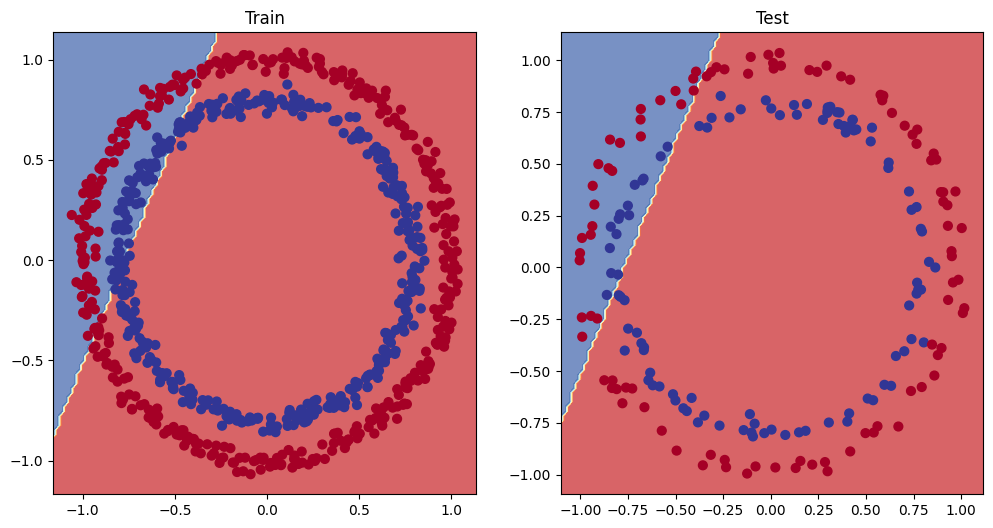

In [39]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)
plt.show()

## Improving model
* Add more layers
* Add more hidden units or neurons
* Fit for longer
* Change activn fn or lr
* Change loss fn
* Change **Data** or **Hyperparameters**

In [40]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0473, -0.6888],
                      [ 0.3400,  0.4700],
                      [ 0.4961, -0.0384],
                      [ 0.1734, -0.6827],
                      [ 0.4472, -0.0226]])),
             ('0.bias', tensor([-0.1118, -0.3356,  0.6347, -0.3759, -0.0920])),
             ('1.weight',
              tensor([[ 0.3425,  0.0777, -0.2994, -0.4026,  0.0316]])),
             ('1.bias', tensor([-0.0436]))])

In [41]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    x = torch.relu(self.layer_1(x))
    x = torch.relu(self.layer_2(x))
    return self.layer_3(x)

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

```class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Sequential chains layers and activations automatically
        self.network = nn.Sequential(
            nn.Linear(in_features=2, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=1)
        )
  
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

model_1 = CircleModelV1().to(device)
print(model_1)

Without Sequential -> relu in forward def as they are not linked like Sequential

In [42]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.01)
# Adam handles complex & non linear decision boundary much faster

In [43]:
torch.manual_seed(42)
epochs = 200
epoch_count=[]
loss_values=[]
train_acc_his=[]
test_loss_values=[]
test_acc_his=[]

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Training
for epoch in range(epochs):
  model_1.train()
  y_logits = model_1(X_train).squeeze(dim=1)
  loss = loss_fn(y_logits, y_train)

  y_pred_labels = torch.round(torch.sigmoid(y_logits))
  train_acc=accuracy_fn(y_true=y_train, y_pred=y_pred_labels)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_pred_labels = torch.round(torch.sigmoid(test_logits))
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred_labels)


  epoch_count.append(epoch)
  loss_values.append(loss.item()) # loss contain tensor, so to pull out float --> use .item()
  train_acc_his.append(train_acc)
  test_loss_values.append(test_loss.item())
  test_acc_his.append(test_acc)
  if epoch % 10 == 0:
    print(f"Epoch: {epoch:3d} | Loss: {loss:.5f} | Train Acc: {train_acc:.2f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")


Epoch:   0 | Loss: 0.69295 | Train Acc: 50.00 | Test Loss: 0.69203 | Test Acc: 55.50
Epoch:  10 | Loss: 0.68651 | Train Acc: 53.00 | Test Loss: 0.68401 | Test Acc: 56.50
Epoch:  20 | Loss: 0.67698 | Train Acc: 53.50 | Test Loss: 0.67149 | Test Acc: 57.00
Epoch:  30 | Loss: 0.66078 | Train Acc: 60.75 | Test Loss: 0.65295 | Test Acc: 62.00
Epoch:  40 | Loss: 0.63241 | Train Acc: 66.87 | Test Loss: 0.62340 | Test Acc: 70.00
Epoch:  50 | Loss: 0.58509 | Train Acc: 74.25 | Test Loss: 0.57695 | Test Acc: 76.50
Epoch:  60 | Loss: 0.52041 | Train Acc: 81.50 | Test Loss: 0.52935 | Test Acc: 81.00
Epoch:  70 | Loss: 0.43584 | Train Acc: 90.75 | Test Loss: 0.45495 | Test Acc: 89.00
Epoch:  80 | Loss: 0.33954 | Train Acc: 96.50 | Test Loss: 0.35861 | Test Acc: 95.50
Epoch:  90 | Loss: 0.24768 | Train Acc: 98.50 | Test Loss: 0.27244 | Test Acc: 97.00
Epoch: 100 | Loss: 0.17334 | Train Acc: 99.62 | Test Loss: 0.20684 | Test Acc: 99.00
Epoch: 110 | Loss: 0.12108 | Train Acc: 99.87 | Test Loss: 0.1501

In [44]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.7572,  1.8043],
                      [-1.4144,  1.6653],
                      [-0.1549,  0.1427],
                      [-2.2588, -0.5139],
                      [ 0.0659, -2.3239],
                      [ 1.9843,  0.2563],
                      [ 1.8275, -0.9665],
                      [ 0.3410, -0.0998],
                      [ 0.5002,  1.6184],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-1.4317, -1.3485, -0.2872, -0.9782, -1.1131, -1.1428, -1.2370, -0.4252,
                      -0.4350, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-1.0006, -1.6576,  0.2441, -1.4208, -1.5904, -1.4003, -1.1914,  0.2555,
                       -0.6897, -0.0997],
                      [ 1.3262,  1.4694,  0.1331,  1.9706,  1.8520,  1.5318,  1.7354,  0.0566,
                        1.6252, -0.1927],
                      [-0.3695, -0.205

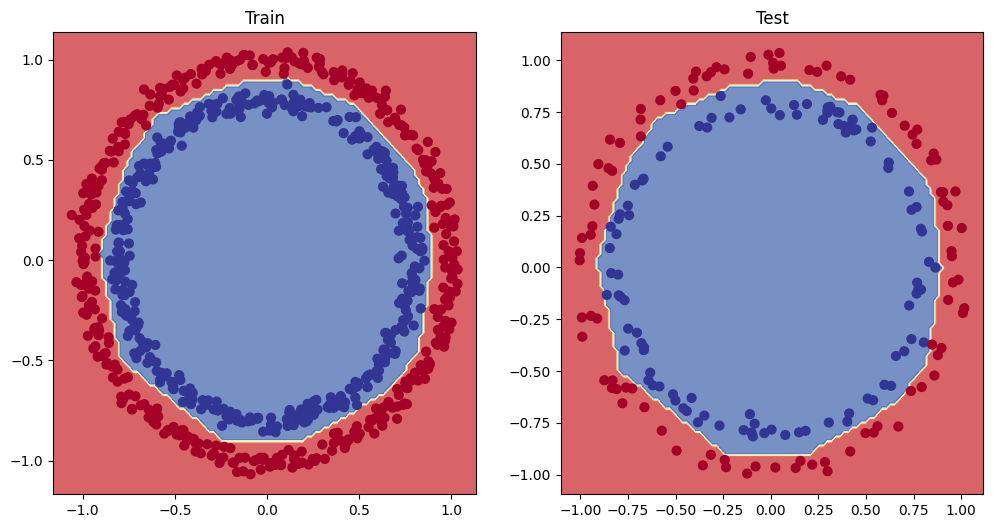

In [45]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)
plt.show()

Plot predictions use matplotlib --> behind the scences numpy uses "cpu"

In [46]:
print(X_test.shape, y_test.shape, test_pred_labels.shape)

torch.Size([200, 2]) torch.Size([200]) torch.Size([200])


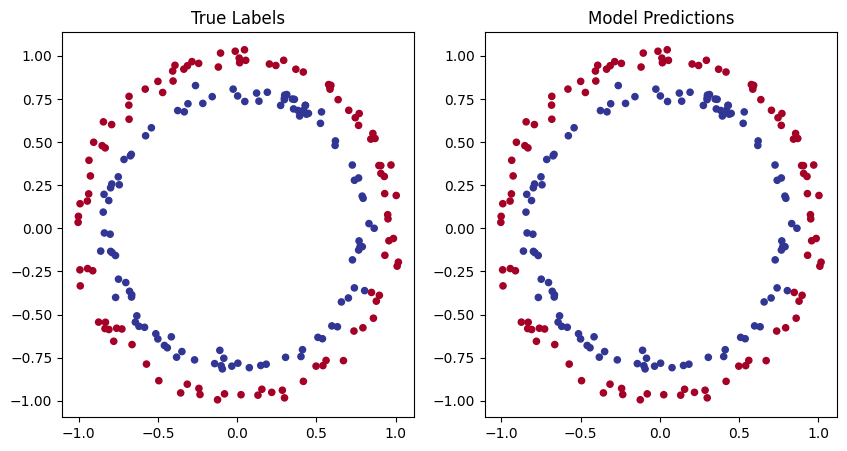

In [47]:
# 1. Convert tensors to numpy arrays
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()
preds_np = test_pred_labels.cpu().numpy()

# 2. Create the plot
plt.figure(figsize=(10, 5))

# Plot True Labels
plt.subplot(1, 2, 1)
plt.title("True Labels")
plt.scatter(X_test_np[:, 0], X_test_np[:, 1], c=y_test_np, cmap=plt.cm.RdYlBu, s=20)

# Plot Your Model's Predictions
plt.subplot(1, 2, 2)
plt.title("Model Predictions")
plt.scatter(X_test_np[:, 0], X_test_np[:, 1], c=preds_np, cmap=plt.cm.RdYlBu, s=20)
plt.show()


## Multiclassification Problem

### Creating toy dataset

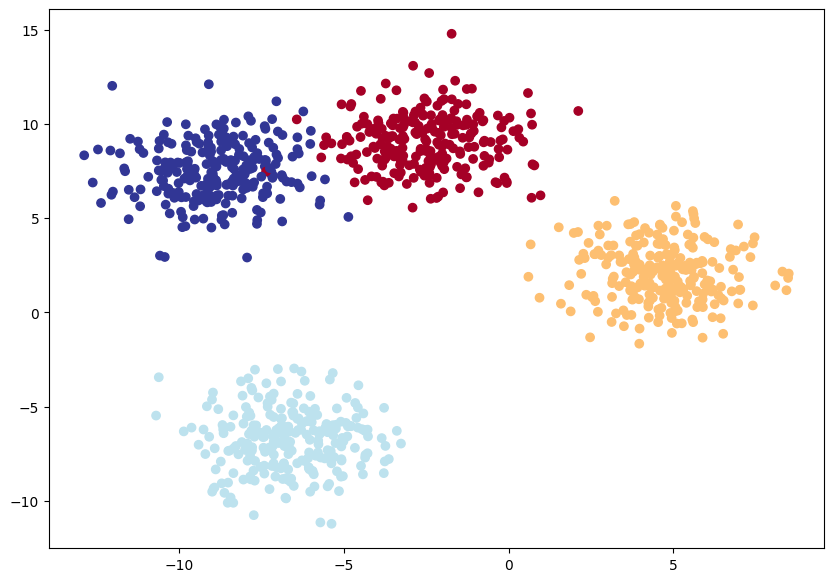

In [48]:
from sklearn.datasets import make_blobs

# Setting Hyperparams for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED
                            )

# Numpy to Tensor
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor) # As argmax will give us the index in int64

# Splitting
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

# Visualize
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)
plt.show()

In [49]:
X_blob_train.shape, X_blob_test.shape, y_blob_train.shape, y_blob_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [50]:
X_blob_train.dtype, X_blob_test.dtype, y_blob_train.dtype, y_blob_test.dtype

(torch.float32, torch.float32, torch.int64, torch.int64)

In [51]:
y_blob_train.unique(return_counts=True), y_blob_test.unique(return_counts=True)

((tensor([0, 1, 2, 3]), tensor([201, 209, 197, 193])),
 (tensor([0, 1, 2, 3]), tensor([49, 41, 53, 57])))

### Creating a multiclassification model

In [52]:
# Creating device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [53]:
# Building a Multiclassification Model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    # Hidden Units -> Hidden layers number
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x: torch.Tensor)-> torch.Tensor:
    return self.linear_layer_stack(x)

model_2 = BlobModel(input_features=2, output_features=4, hidden_units=8)
model_2, model_2.to(device)

(BlobModel(
   (linear_layer_stack): Sequential(
     (0): Linear(in_features=2, out_features=8, bias=True)
     (1): ReLU()
     (2): Linear(in_features=8, out_features=8, bias=True)
     (3): ReLU()
     (4): Linear(in_features=8, out_features=4, bias=True)
   )
 ),
 BlobModel(
   (linear_layer_stack): Sequential(
     (0): Linear(in_features=2, out_features=8, bias=True)
     (1): ReLU()
     (2): Linear(in_features=8, out_features=8, bias=True)
     (3): ReLU()
     (4): Linear(in_features=8, out_features=4, bias=True)
   )
 ))

In [54]:
model_2.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998]], device='cuda:0')),
             ('linear_layer_stack.0.bias',
              tensor([ 0.5451,  0.1045, -0.3301,  0.1802, -0.3258, -0.0829, -0.2872,  0.4691],
                     device='cuda:0')),
             ('linear_layer_stack.2.weight',
              tensor([[-0.2791, -0.1630, -0.0998, -0.2126,  0.0334, -0.3492,  0.3193, -0.3003],
                      [ 0.2730,  0.0588, -0.1148,  0.2185,  0.0551,  0.2857,  0.0387, -0.1115],
                      [ 0.0950, -0.0959,  0.1488,  0.3157,  0.2044, -0.1546,  0.2041,  0.0633],
                      [ 0.1795, -0.2155, -0.3500, -0.1366, -0.2712,  0.2901,  0.1018,  0

In [55]:
# Loss
loss_fn = nn.CrossEntropyLoss() # This uses raw indices (int64) to calculate scores
# Optimizer
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

* nn.CrossEntropyLoss expects targets to be long.Tensor(int64)

In [56]:
# Training Loop
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

epochs = 100
epoch_count=[]
loss_values=[]
train_acc_his=[]
test_loss_values=[]
test_acc_his=[]

# Data to device
X_blob_train = X_blob_train.to(device)
y_blob_train = y_blob_train.to(device)
X_blob_test = X_blob_test.to(device)
y_blob_test = y_blob_test.to(device)

for epoch in range(epochs):
  model_2.train()

  y_logits = model_2(X_blob_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
  # torch.softmax converts raw logits into prob scores, and argmax gives index with max value/prob.
  # dim=1 : calculate these percentages across the columns (the classes) for each row (each sample).

  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_logits = model_2(X_blob_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

  epoch_count.append(epoch)
  loss_values.append(loss.item()) # loss contain tensor, so to pull out float --> use .item()
  train_acc_his.append(acc)
  test_loss_values.append(test_loss.item())
  test_acc_his.append(test_acc)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch:3d} | Loss: {loss:.5f} | Train Acc: {acc:.2f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

Epoch:   0 | Loss: 1.15883 | Train Acc: 40.38 | Test Loss: 1.07554 | Test Acc: 48.00
Epoch:  10 | Loss: 0.64476 | Train Acc: 96.75 | Test Loss: 0.66069 | Test Acc: 97.50
Epoch:  20 | Loss: 0.42535 | Train Acc: 98.50 | Test Loss: 0.43074 | Test Acc: 100.00
Epoch:  30 | Loss: 0.25294 | Train Acc: 99.12 | Test Loss: 0.24508 | Test Acc: 99.50
Epoch:  40 | Loss: 0.11232 | Train Acc: 99.25 | Test Loss: 0.10229 | Test Acc: 99.50
Epoch:  50 | Loss: 0.06627 | Train Acc: 99.25 | Test Loss: 0.05848 | Test Acc: 99.50
Epoch:  60 | Loss: 0.05068 | Train Acc: 99.25 | Test Loss: 0.04293 | Test Acc: 99.50
Epoch:  70 | Loss: 0.04300 | Train Acc: 99.25 | Test Loss: 0.03491 | Test Acc: 99.50
Epoch:  80 | Loss: 0.03836 | Train Acc: 99.25 | Test Loss: 0.02988 | Test Acc: 99.50
Epoch:  90 | Loss: 0.03525 | Train Acc: 99.25 | Test Loss: 0.02663 | Test Acc: 99.50


In [57]:
model_2.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.8513,  0.9128],
                      [-0.2366,  0.7121],
                      [-0.7736, -0.2783],
                      [-0.5359,  0.7688],
                      [ 0.5275, -0.5448],
                      [ 0.6801,  0.4767],
                      [ 0.5925,  0.0862],
                      [ 0.5249, -0.0629]], device='cuda:0')),
             ('linear_layer_stack.0.bias',
              tensor([ 0.6350,  0.0886, -0.2677,  0.1639, -0.3468,  0.0008, -0.2684,  0.5212],
                     device='cuda:0')),
             ('linear_layer_stack.2.weight',
              tensor([[-0.2791, -0.1630, -0.0998, -0.2126,  0.0334, -0.3492,  0.3193, -0.3003],
                      [ 0.7828,  0.2664, -0.2843,  0.2962,  0.0063,  0.3015,  0.0052, -0.1573],
                      [-0.3534,  0.1929,  0.2791,  0.7564,  0.1406, -0.2573,  0.1589,  0.0214],
                      [ 0.2855, -0.2310, -0.3519, -0.1681, -0.2339,  0.3772,  0.1672,  0

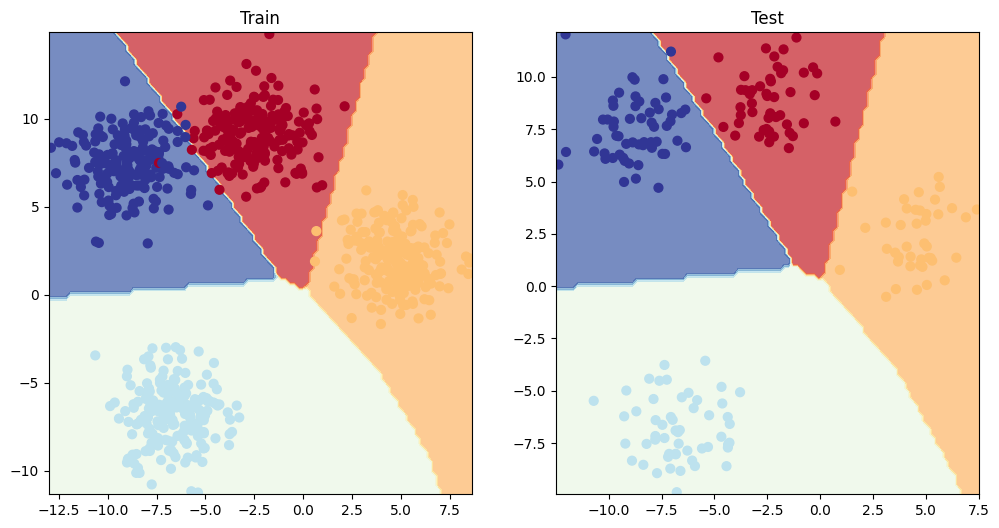

In [58]:
# Plotting decision Boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2, X_blob_test, y_blob_test)
plt.show()

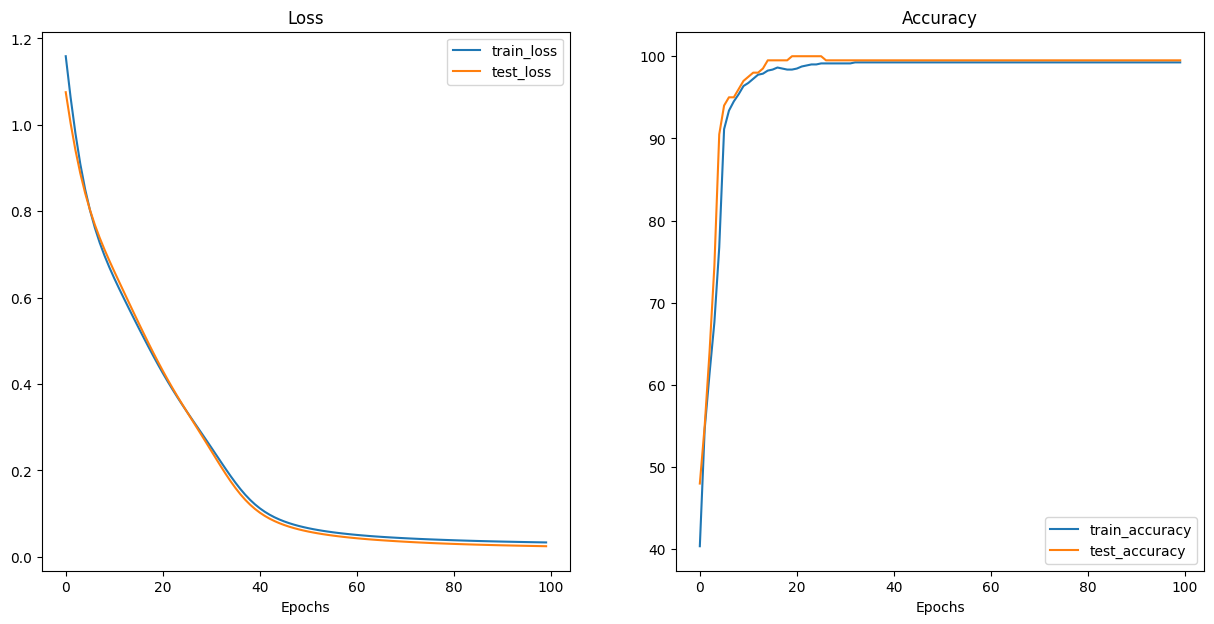

In [59]:
# 1. Put your training data into a dictionary matching the names your function expects
history_dict = {
    "train_loss": loss_values,
    "train_acc": train_acc_his,
    "test_loss": test_loss_values,
    "test_acc": test_acc_his
}

# 2. Pass that dictionary directly into your helper function
plot_loss_curves(history_dict)

* Matplotlib and NumPy cannot read or interact with GPU tensors.
* NumPy Requires CPU Memory
* Matplotlib Only Renders CPU Tensors

In [60]:
# Force the model back to your device right before predicting as plt.plot_pred moved it to cpu
model_2 = model_2.to(device)

model_2.eval()
with torch.inference_mode():
    # Remember to use unsqueeze(0) to add the batch dimension! or else dim will shape will be only X[single_feature]
    single_logit = model_2(X_blob_test[0].to(device).unsqueeze(0))
    single_prob = torch.softmax(single_logit, dim=1)
    single_pred = single_prob.argmax(dim=1)

y_blob_test[0].item() == single_pred.item()

# We can get class label even from logits but if we want confidence score of a class -> use softmax

True

In [61]:
# Sum of probs of all classes for a training ex : 1
torch.sum(single_prob, dim=1)

tensor([1.0000], device='cuda:0')

In [62]:
!pip install torchmetrics

In [63]:
import torchmetrics
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
# Classification Report deos not exist in torchmetrics, only in SkLearn

In [64]:
acc_fn = Accuracy(task="multiclass", num_classes=4).to(device)
precision_fn = Precision(task="multiclass", num_classes=4).to(device)
recall_fn = Recall(task="multiclass", num_classes=4).to(device)
f1_fn = F1Score(task="multiclass", num_classes=4).to(device)
cm_fn = ConfusionMatrix(task="multiclass", num_classes=4).to(device)

In [65]:
acc_fn(test_pred, y_blob_test)

tensor(0.9950, device='cuda:0')

In [66]:
precision_fn(test_pred, y_blob_test)

tensor(0.9950, device='cuda:0')

In [67]:
recall_fn(test_pred, y_blob_test)

tensor(0.9950, device='cuda:0')

In [68]:
f1_fn(test_pred, y_blob_test)

tensor(0.9950, device='cuda:0')

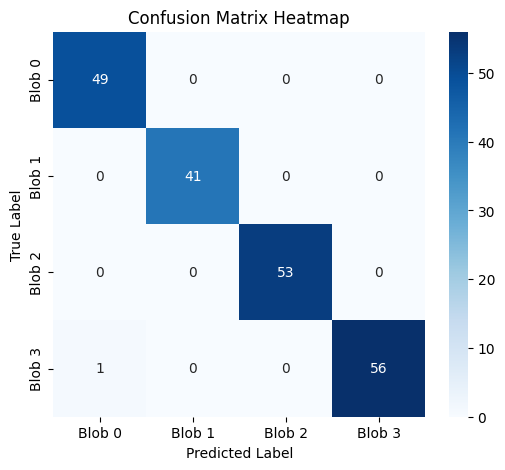

In [69]:
# 1. Compute the matrix array on the CPU
# (Make sure to move tensors to CPU or call .detach() for plotting)
conf_matrix = cm_fn(test_pred, y_blob_test).cpu().numpy()

# 2. Plot it visually using a seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Blob 0", "Blob 1", "Blob 2", "Blob 3"],
            yticklabels=["Blob 0", "Blob 1", "Blob 2", "Blob 3"])
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Saving and Loading a Model

In [70]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "02_neural_network_classification.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/02_neural_network_classification.pth


In [71]:
model_2.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.8513,  0.9128],
                      [-0.2366,  0.7121],
                      [-0.7736, -0.2783],
                      [-0.5359,  0.7688],
                      [ 0.5275, -0.5448],
                      [ 0.6801,  0.4767],
                      [ 0.5925,  0.0862],
                      [ 0.5249, -0.0629]], device='cuda:0')),
             ('linear_layer_stack.0.bias',
              tensor([ 0.6350,  0.0886, -0.2677,  0.1639, -0.3468,  0.0008, -0.2684,  0.5212],
                     device='cuda:0')),
             ('linear_layer_stack.2.weight',
              tensor([[-0.2791, -0.1630, -0.0998, -0.2126,  0.0334, -0.3492,  0.3193, -0.3003],
                      [ 0.7828,  0.2664, -0.2843,  0.2962,  0.0063,  0.3015,  0.0052, -0.1573],
                      [-0.3534,  0.1929,  0.2791,  0.7564,  0.1406, -0.2573,  0.1589,  0.0214],
                      [ 0.2855, -0.2310, -0.3519, -0.1681, -0.2339,  0.3772,  0.1672,  0

In [72]:
loaded_model_2 = BlobModel(input_features=2, output_features=4, hidden_units=8)
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2.to(device)

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [73]:
next(model_2.parameters()).device

device(type='cuda', index=0)

In [74]:
model_2.eval()
with torch.inference_mode():
  model_2_preds = model_2(X_test)
  loaded_model_2_preds = loaded_model_2(X_test)
are_equal = (model_2_preds == loaded_model_2_preds).all()
are_equal

tensor(True, device='cuda:0')